Statistcs of True_error compared to absolute error and signed error

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import scikit_posthocs as sp

In [29]:
df = pd.read_csv("Output_extraction/ai_grading_final_v2.csv")

df["prompt_type"] = pd.Categorical(df["prompt_type"], 
    categories=["very_pessimistic", "pessimistic", "neutral", "confident", "very_confident"], 
    ordered=True)

required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
df = df.dropna()

df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])

df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

pd.set_option("display.max_rows", None)

We start with a simple comparison in a table

In [30]:
display(
    df.groupby("true_mistakes")[
        ["ai_error", "Absolute_error"]
    ].agg(["count", "mean", "std"])
)

ai_error                     Absolute_error                    
                 count      mean       std          count      mean       std
true_mistakes                                                                
0                  250  0.124000  0.416314            250  0.124000  0.416314
1                  500  0.338000  1.168969            500  0.362000  1.161747
2                  250  0.284000  0.889104            250  0.316000  0.878196
3                  500  0.208000  0.762824            500  0.276000  0.740893
4                  250  0.116000  0.572587            250  0.180000  0.555730
5                  500  0.150000  0.693153            500  0.250000  0.663612
6                  250  0.096000  0.795812            250  0.296000  0.744716
7                  500  0.044000  0.516331            500  0.188000  0.482827
8                  250 -0.044000  0.602925            250  0.260000  0.545518
9                  500 -0.092000  0.693179            500  0.288000  0.637077
10                 249 -0.100402  0.702788            249  0.293173  0.646325
11                 500 -0.154000  0.641176            500  0.270000  0.601518
12                 250 -0.296000  0.845722            250  0.392000  0.805563
13                 499 -0.382766  0.926941            499  0.434870  0.903622
14                 249 -0.405622  0.879956            249  0.421687  0.872341
15                 500 -0.466000  1.219762            500  0.466000  1.219762

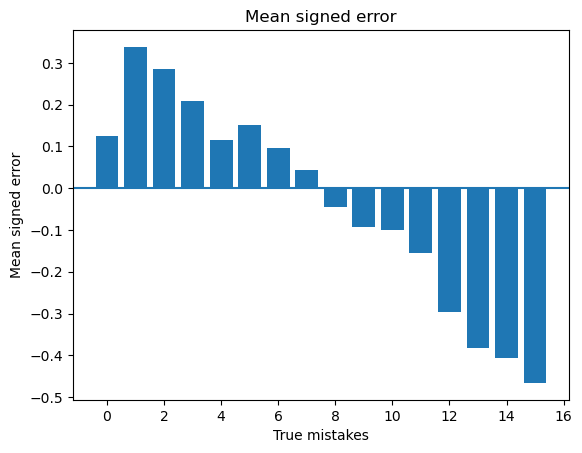

In [31]:
summary = df.groupby("true_mistakes")["ai_error"].agg(["mean", "std", "count"])


plt.bar(
    summary.index,
    summary["mean"],
    capsize=5
)

plt.axhline(0)
plt.xlabel("True mistakes")
plt.ylabel("Mean signed error")
plt.title("Mean signed error")
plt.show()

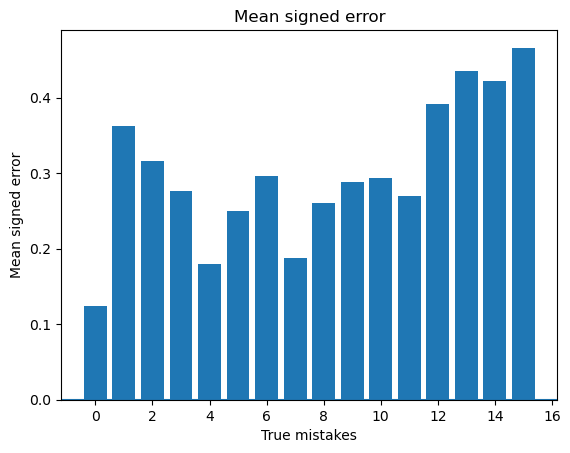

In [32]:
summary = df.groupby("true_mistakes")["Absolute_error"].agg(["mean", "std", "count"])


plt.bar(
    summary.index,
    summary["mean"],
    capsize=5
)

plt.axhline(0)
plt.xlabel("True mistakes")
plt.ylabel("Mean signed error")
plt.title("Mean signed error")
plt.show()

In [33]:
# ── Kruskal-Wallis for true_mistakes ───────────────────────────────────────────

# Med ai_error (signed)
kw_signed = pg.kruskal(
    data=df,
    dv="ai_error",
    between="true_mistakes"
)
print("=== Kruskal-Wallis: ai_error (signed) ===")
print(kw_signed)

# Med Absolute_error
kw_absolute = pg.kruskal(
    data=df,
    dv="Absolute_error",
    between="true_mistakes"
)
print("\n=== Kruskal-Wallis: Absolute_error ===")
print(kw_absolute)

=== Kruskal-Wallis: ai_error (signed) ===
                Source  ddof1           H          p_unc
Kruskal  true_mistakes     15  524.676219  3.383189e-102

=== Kruskal-Wallis: Absolute_error ===
                Source  ddof1          H         p_unc
Kruskal  true_mistakes     15  64.978349  3.446919e-08


Now using dunns becouse we see the p value is significant

In [34]:
def dunn_test(data, outcome):
    # Fjern eventuelle manglende værdier
    clean = data[["true_mistakes", outcome]].dropna()

    # Dunn-test med Holm-korrektion
    p_values = sp.posthoc_dunn(
        clean,
        val_col=outcome,
        group_col="true_mistakes",
        p_adjust="holm"
    )

    # Behold kun hver sammenligning én gang
    mask = np.triu(np.ones(p_values.shape, dtype=bool), k=1)

    results = (
        p_values
        .where(mask)
        .rename_axis(index="A", columns="B")
        .stack()
        .reset_index(name="p_corr")
        .dropna(subset=["p_corr"])
        .reset_index(drop=True)
    )

    return results

signed error

In [35]:
posthoc_signed_true = dunn_test(df, "ai_error")

display(posthoc_signed_true)
display(posthoc_signed_true[posthoc_signed_true["p_corr"] < 0.05])

,A,B,p_corr
0,0,1,1.000000e+00
1,0,2,1.000000e+00
2,0,3,1.000000e+00
3,0,4,1.000000e+00
4,0,5,1.000000e+00
5,0,6,1.000000e+00
6,0,7,9.439266e-01
7,0,8,1.157534e-02
8,0,9,2.363088e-04
9,0,10,2.695754e-03


,A,B,p_corr
7,0,8,1.157534e-02
8,0,9,2.363088e-04
9,0,10,2.695754e-03
10,0,11,3.185312e-08
11,0,12,2.374284e-10
12,0,13,8.060604e-18
13,0,14,5.345311e-17
14,0,15,1.597538e-19
20,1,7,1.645350e-02
21,1,8,4.188554e-05


Absolute error

In [36]:
posthoc_absolute_true = dunn_test(df, "Absolute_error")

print("\n=== Dunn's post-hoc test: absolute error ===")
display(posthoc_absolute_true)
display(posthoc_absolute_true[posthoc_absolute_true["p_corr"] < 0.05])


=== Dunn's post-hoc test: absolute error ===


,A,B,p_corr
0,0,1,1.000000
1,0,2,1.000000
2,0,3,0.953466
3,0,4,1.000000
4,0,5,1.000000
5,0,6,0.574699
6,0,7,1.000000
7,0,8,0.162110
8,0,9,0.035649
9,0,10,0.249272


,A,B,p_corr
8,0,9,0.035649
10,0,11,0.039942
11,0,12,0.004726
12,0,13,0.000027
13,0,14,0.000473
14,0,15,0.005382
26,1,13,0.002814
27,1,14,0.035649
62,4,13,0.004039
63,4,14,0.023165
